In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
from BIGFAM import obj1, tools
from tqdm import tqdm

In [2]:
# ad-hoc functions
def simul_frreg(G, S, w, dor):
    """Make FR-reg coefficient.
    
    G : heritability
    S : variance component by shared env (d=1)
    w : decaying parameter for S
    dor : degree of relatedness
    """
    by_G = G * (1/2)**dor
    by_S = S * (1/w)**(dor-1)
    
    return by_G + by_S

# Step 1. FRLog-reg with various variance components

test $H_0$ while varying $\sigma^2_g$, $\sigma^2_s$, $w$, and $\epsilon$ 

In [3]:
G = 0.5
S = 0.05
w = 5
se_frreg = 5e-3

pd.DataFrame({
                "DOR": [1, 2, 3],
                "slope": [simul_frreg(G, S, w, d) for d in range(1, 4)],
                "se": se_frreg,
            })

,DOR,slope,se
0,1,0.3000,0.005
1,2,0.1350,0.005
2,3,0.0645,0.005


In [14]:
df_frlog = pd.DataFrame(columns=["G", "S", "w", "sig", "slope", "intercept"])
se_frreg = 5e-3

for G in tqdm(np.arange(0.2, 0.8, 0.2)):
    for S in np.arange(0.05, 0.3, 0.05):
        for w in np.arange(1.1, 4, 0.3):
        
            df_frreg = pd.DataFrame({
                "DOR": [1, 2, 3],
                "slope": [simul_frreg(G, S, w, d) for d in range(1, 4)],
                "se": se_frreg,
            })
            
            # generate 100 resampled FR-reg coefficients 
            df_lmbds = obj1.resampleFrregCoefficients(
                df_frreg, 
                n_resample=100
            )    
            df_frlogreg = obj1.familialRelationshipLogRegression(df_lmbds)
            
            frlogreg_sig = "None"
            if (np.percentile(df_frlogreg["slope"], 2.5) > 1):
                frlogreg_sig = "High"
            if (np.percentile(df_frlogreg["slope"], 97.5) < 1):
                frlogreg_sig = "Low"
                
            df_frlog.loc[len(df_frlog)] = [G, S, w, frlogreg_sig,
                                           df_frlogreg["slope"].values[0], df_frlogreg["intercept"].values[0]]



100%|██████████| 4/4 [01:41<00:00, 25.47s/it]


In [13]:
df_frlog.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/frlog/frlog_gsw_e5e-3.tsv",
    sep='\t',
    index=False
)

0.4974354734371746

# Step.2 Plot

## Step 2.1 plot reject $H_0$ ratio

In [3]:
es = ["1e-3", "5e-3", "1e-2"]
df_tmp = pd.DataFrame(columns=[
    "e", "w_true", "n_reject_null", "n_not_reject_null"
])

for e in es:
    frlog_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/frlog/frlog_gsw_e{e}.tsv"
    df_frlog = pd.read_csv(frlog_fn,
                           sep='\t')
    df_frlog["true_sig"] = 0
    df_frlog.loc[df_frlog["w"] < 1.9, "true_sig"] = -1
    df_frlog.loc[df_frlog["w"] > 2.1, "true_sig"] = 1
    df_frlog["w"] = df_frlog["w"].round(2)
    
    true_null = df_frlog["true_sig"] == 0
    test_null = df_frlog["sig"] == 0

    tn = df_frlog[true_null & test_null].shape[0]
    fn = df_frlog[~true_null & test_null].shape[0]
    fp = df_frlog[true_null & ~test_null].shape[0]
    tp = df_frlog[~true_null & ~test_null].shape[0]
    # print(f"TN : {tn}")
    # print(f"FN : {fn}")
    # print(f"FP : {fp}")
    # print(f"TP : {tp}")
    
    for w in df_frlog["w"].unique():
        tmp = df_frlog[df_frlog["w"] == w]
        n_reject_null = tmp[(tmp["sig"] != 0)].shape[0]
        n_not_reject_null = tmp[(tmp["sig"] == 0)].shape[0]
        df_tmp.loc[len(df_tmp)] = [e, w, n_reject_null/20, n_not_reject_null/20]

In [4]:
df_tmp

,e,w_true,n_reject_null,n_not_reject_null
0,1e-3,1.1,1.00,0.00
1,1e-3,1.4,1.00,0.00
2,1e-3,1.7,1.00,0.00
3,1e-3,2.0,0.00,1.00
4,1e-3,2.3,1.00,0.00
5,1e-3,2.6,1.00,0.00
6,1e-3,2.9,1.00,0.00
7,1e-3,3.2,1.00,0.00
8,1e-3,3.5,1.00,0.00
9,1e-3,3.8,1.00,0.00


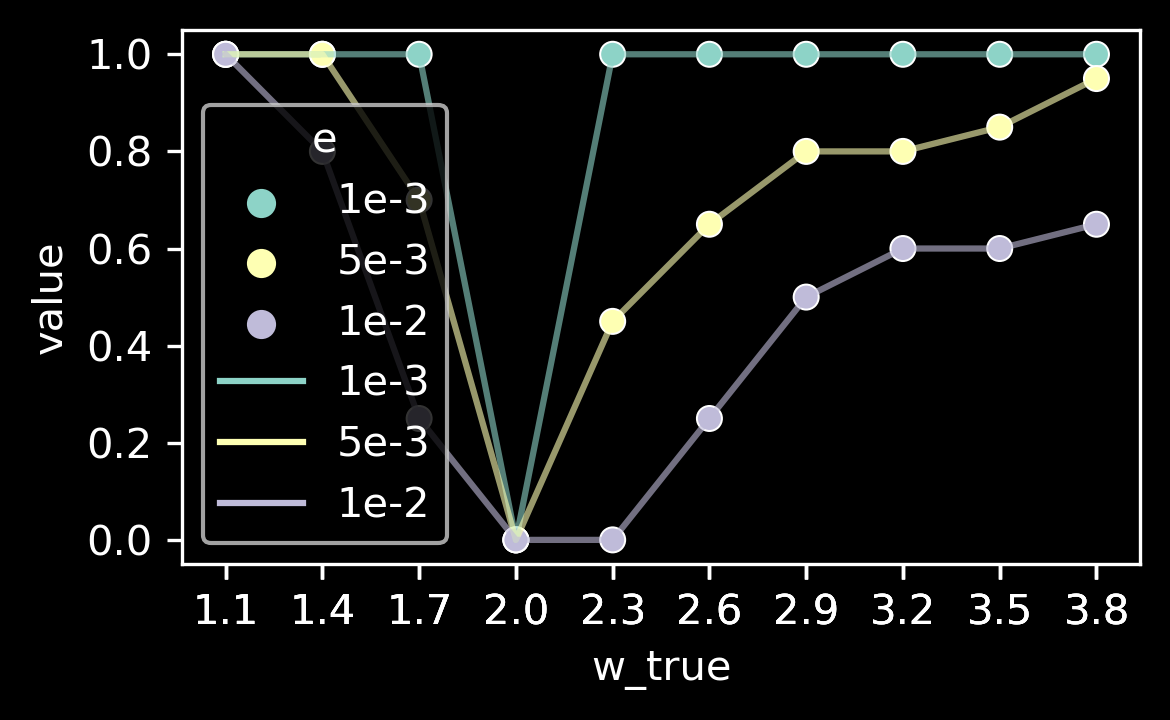

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), dpi=300) 

tt = pd.melt(df_tmp, id_vars=["e", "w_true"])
tt = tt[tt["variable"] == "n_reject_null"]

sns.scatterplot(
    data=tt,
    x="w_true",
    y="value",
    hue="e",
    alpha=1,
    ax=ax
)    
sns.lineplot(
    data=tt,
    x="w_true",
    y="value",
    hue="e",
    alpha=0.6,
    ax=ax
)
# sns.despine(offset=0.1, trim=True);

ax.set_xticks(df_tmp["w_true"].to_list())

plt.tight_layout();

## Step 2.2 plot reject H0 scatter plot

In [6]:
df_frlog = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/frlog/frlog_gsw_e5e-3.tsv",
    sep='\t'
)

In [7]:
df_frlog["true_sig"] = 0
df_frlog.loc[df_frlog["w"] < 1.9, "true_sig"] = -1
df_frlog.loc[df_frlog["w"] > 2.1, "true_sig"] = 1
df_frlog["w"] = df_frlog["w"].round(2)

In [8]:
df_frlog.head()

,G,S,w,sig,warning,slope,intercept,true_sig
0,0.2,0.05,1.1,-1,False,0.582676,-2.164943,-1
1,0.2,0.05,1.4,-1,False,0.784812,-1.970822,-1
2,0.2,0.05,1.7,0,False,0.913492,-1.820396,-1
3,0.2,0.05,2.0,0,False,1.009022,-1.722746,0
4,0.2,0.05,2.3,0,False,1.046993,-1.693752,1


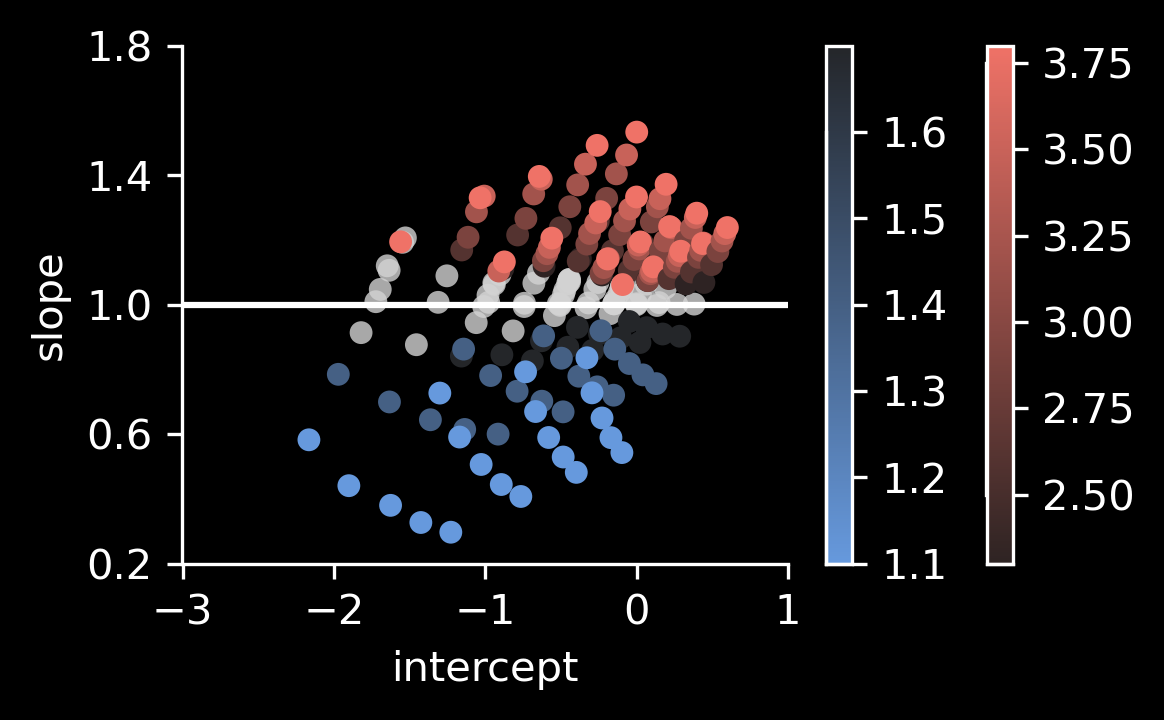

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), dpi=300)

# can't reject null
sns.scatterplot(x="intercept",
                y="slope",
                data=df_frlog[df_frlog["sig"] == 0],
                ax=ax,
                color="lightgrey",
                s=30,
                edgecolor="None",
                alpha=0.8)
# more
palette_more = sns.dark_palette("#ef7267", reverse=False, as_cmap=True)
norm_more = plt.Normalize(df_frlog.loc[df_frlog["sig"] == 1, "w"].min(),
                          df_frlog.loc[df_frlog["sig"] == 1, "w"].max())
sm_more = plt.cm.ScalarMappable(cmap=palette_more, 
                                norm=norm_more)
sns.scatterplot(x="intercept",
                y="slope",
                hue="w",
                data=df_frlog[df_frlog["sig"] == 1],
                ax=ax,
                s=30,
                edgecolor="None",
                palette=palette_more)

# Less
palette_less = sns.dark_palette("#6699dd", reverse=True, as_cmap=True)
norm_less = plt.Normalize(df_frlog.loc[df_frlog["sig"] == -1, "w"].min(),
                          df_frlog.loc[df_frlog["sig"] == -1, "w"].max())
sm_less = plt.cm.ScalarMappable(cmap=palette_less, 
                                norm=norm_less)
sns.scatterplot(x="intercept",
                y="slope",
                hue="w",
                data=df_frlog[df_frlog["sig"] == -1],
                ax=ax,
                s=30,
                edgecolor="None",
                palette=palette_less)
# reference
ax.axhline(1)
ax.set_xticks([-3, -2, -1, 0, 1])
ax.set_yticks([0.2, 0.6, 1, 1.4, 1.8])

# colorbar
ax.get_legend().remove()
ax.figure.colorbar(sm_more, ax=ax)
ax.figure.colorbar(sm_less, ax=ax)

sns.despine(offset=0.1, trim=True);

plt.tight_layout();